<a href="https://colab.research.google.com/github/Sivanunna/Logicmojo-AI-ML-Sept25--siva-/blob/main/gradution_factors_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import pandas as pd
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Filtering out the warnings
import warnings
warnings.filterwarnings('ignore')

In [11]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Admission_Predict.csv')
df

Mounted at /content/drive


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
395,396,324,110,3,3.5,3.5,9.04,1,0.82
396,397,325,107,3,3.0,3.5,9.11,1,0.84
397,398,330,116,4,5.0,4.5,9.45,1,0.91
398,399,312,103,3,3.5,4.0,8.78,0,0.67


In [12]:
df['Admit'] = df['Chance of Admit '] > 0.7
df['Admit'] = df['Admit'].astype(int)
df['Admit']

,Admit
0,1
1,1
2,1
3,1
4,0
...,...
395,1
396,1
397,1
398,0


In [13]:
df.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit ', 'Admit'],
      dtype='object')

In [14]:
df.drop('Serial No.',axis=1,inplace=True)

In [15]:
df.drop('University Rating',axis=1,inplace=True)

In [16]:
df.drop('Chance of Admit ',axis=1,inplace=True)

In [17]:
Conversion_rate = (sum(df['Admit'])/len(df['Admit'].index))*100
Conversion_rate

58.75

In [18]:
y = df['Admit']
x = df.drop('Admit',axis=1)

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42
)

In [20]:
from sklearn import linear_model
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
from sklearn import preprocessing

In [21]:
logm1 = sm.GLM(y_train,(sm.add_constant(X_train)),family = sm.families.Binomial())
logm1.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  Admit   No. Observations:                  280
Model:                            GLM   Df Residuals:                      273
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -89.584
Date:                Tue, 03 Mar 2026   Deviance:                       179.17
Time:                        09:57:32   Pearson chi2:                     211.
No. Iterations:                     7   Pseudo R-squ. (CS):             0.5065
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -53.6987      8.929     -6.014      0.000     -71.199     -36.199
GRE Score       0.0753      0.034      2.243      0.025       0.010       0.141
TOEFL Score     0.0686      0.058      1.176      0.240      -0.046       0.183
SOP             0.1328      0.298      0.446      0.656      -0.451       0.717
LOR             0.4093      0.311      1.318      0.187      -0.199       1.018
CGPA            2.4440      0.724      3.376      0.001       1.025       3.863
Research        0.9619      0.395      2.434      0.015       0.187       1.736
===============================================================================
"""

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_train_const = sm.add_constant(X_train)
vif = pd.DataFrame()
vif['Feature'] = X_train_const.columns
vif['VIF'] = [
    variance_inflation_factor(X_train_const.values, i)
    for i in range(X_train_const.shape[1])
]

vif.sort_values(by='VIF', ascending=False)

,Feature,VIF
0,const,1471.184965
5,CGPA,4.996107
1,GRE Score,4.588372
2,TOEFL Score,3.941663
3,SOP,2.877200
4,LOR,2.508749
6,Research,1.529303


In [23]:
X_train.drop('SOP',inplace=True,axis=1)

In [24]:
logm1 = sm.GLM(y_train,(sm.add_constant(X_train)),family = sm.families.Binomial())
logm1.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  Admit   No. Observations:                  280
Model:                            GLM   Df Residuals:                      274
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -89.683
Date:                Tue, 03 Mar 2026   Deviance:                       179.37
Time:                        09:57:32   Pearson chi2:                     213.
No. Iterations:                     7   Pseudo R-squ. (CS):             0.5061
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -54.4384      8.787     -6.195      0.000     -71.661     -37.216
GRE Score       0.0751      0.034      2.240      0.025       0.009       0.141
TOEFL Score     0.0758      0.056      1.349      0.177      -0.034       0.186
LOR             0.4804      0.267      1.796      0.072      -0.044       1.005
CGPA            2.4730      0.719      3.439      0.001       1.064       3.882
Research        0.9584      0.395      2.429      0.015       0.185       1.732
===============================================================================
"""

In [25]:
X_train.drop('TOEFL Score',inplace=True,axis=1)

In [26]:
logm1 = sm.GLM(y_train,(sm.add_constant(X_train)),family = sm.families.Binomial())

result = logm1.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  Admit   No. Observations:                  280
Model:                            GLM   Df Residuals:                      275
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -90.591
Date:                Tue, 03 Mar 2026   Deviance:                       181.18
Time:                        09:57:33   Pearson chi2:                     210.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.5029
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -53.8957      8.658     -6.225      0.000     -70.864     -36.927
GRE Score      0.0934      0.031      3.040      0.002       0.033       0.154
LOR            0.4707      0.266      1.769      0.077      -0.051       0.992
CGPA           2.6818      0.694      3.863      0.000       1.321       4.042
Research       0.9794      0.393      2.494      0.013       0.210       1.749
==============================================================================
"""

In [27]:
y_train_prob = result.predict(sm.add_constant(X_train))
y_train_prob.head()


,0
157,0.154708
109,0.391692
17,0.438712
347,0.003001
24,0.998349


In [28]:
y_train.head()

,Admit
157,0
109,0
17,0
347,0
24,1


In [29]:
train_results = pd.concat([y_train, y_train_prob], axis=1)

In [30]:
train_results.columns = ['Admit', 'Probability']

In [31]:
train_results

,Admit,Probability
157,0,0.154708
109,0,0.391692
17,0,0.438712
347,0,0.003001
24,1,0.998349
...,...,...
71,1,0.999092
106,1,0.989630
270,1,0.295057
348,0,0.004986


In [32]:
train_results['Predicted_Admit'] = train_results['Probability'].map(lambda x : 1 if x > 0.7  else 0)

In [33]:
train_results

,Admit,Probability,Predicted_Admit
157,0,0.154708,0
109,0,0.391692,0
17,0,0.438712,0
347,0,0.003001,0
24,1,0.998349,1
...,...,...,...
71,1,0.999092,1
106,1,0.989630,1
270,1,0.295057,0
348,0,0.004986,0


In [34]:
from sklearn import metrics

In [35]:
confusion = metrics.confusion_matrix(train_results.Admit, train_results.Predicted_Admit )
print(confusion)

[[100  12]
 [ 39 129]]


In [36]:
print(metrics.accuracy_score(train_results.Admit, train_results.Predicted_Admit ))

0.8178571428571428


In [37]:
TP = confusion[1,1] # true positive
TN = confusion[0,0] # true negatives
FP = confusion[0,1] # false positives
FN = confusion[1,0] # false negatives

In [55]:
TP / float(TP+FN)

np.float64(0.7678571428571429)

In [39]:
TN / float(TN+FP)

np.float64(0.8928571428571429)

In [40]:
print(FP/ float(TN+FP))

0.10714285714285714


In [41]:
print (TP / float(TP+FP))

0.9148936170212766


In [42]:
print (TN / float(TN+ FN))

0.7194244604316546


In [43]:
def draw_roc( actual, probs ):
    fpr, tpr, thresholds = metrics.roc_curve( actual, probs,
                                              drop_intermediate = False )
    auc_score = metrics.roc_auc_score( actual, probs )
    plt.figure(figsize=(5, 5))
    plt.plot( fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score )
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc="lower right")
    plt.show()

    return None

In [44]:
fpr, tpr, thresholds = metrics.roc_curve(train_results.Admit, train_results.Predicted_Admit, drop_intermediate = False )

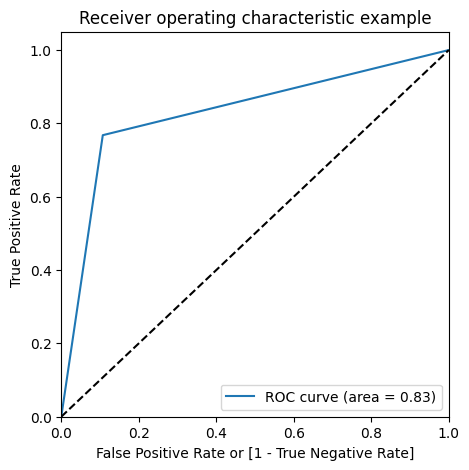

In [45]:
draw_roc(train_results.Admit, train_results.Predicted_Admit)

In [47]:
numbers = [float(x)/10 for x in range(10)]
for i in numbers:
    train_results[i]= train_results.Probability.map(lambda x: 1 if x > i else 0)
train_results.head()

,Admit,Probability,Predicted_Admit,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9
157,0,0.154708,0,1,1,0,0,0,0,0,0,0,0
109,0,0.391692,0,1,1,1,1,0,0,0,0,0,0
17,0,0.438712,0,1,1,1,1,1,0,0,0,0,0
347,0,0.003001,0,1,0,0,0,0,0,0,0,0,0
24,1,0.998349,1,1,1,1,1,1,1,1,1,1,1


In [48]:
# Now let's calculate accuracy sensitivity and specificity for various probability cutoffs.
cutoff_df = pd.DataFrame( columns = ['prob','accuracy','sensi','speci'])
from sklearn.metrics import confusion_matrix

# TP = confusion[1,1] # true positive
# TN = confusion[0,0] # true negatives
# FP = confusion[0,1] # false positives
# FN = confusion[1,0] # false negatives

num = [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
for i in num:
    cm1 = metrics.confusion_matrix(train_results.Admit, train_results[i] )
    total1=sum(sum(cm1))
    accuracy = (cm1[0,0]+cm1[1,1])/total1

    speci = cm1[0,0]/(cm1[0,0]+cm1[0,1])
    sensi = cm1[1,1]/(cm1[1,0]+cm1[1,1])
    cutoff_df.loc[i] =[ i ,accuracy,sensi,speci]
print(cutoff_df)

     prob  accuracy     sensi     speci
0.0   0.0  0.600000  1.000000  0.000000
0.1   0.1  0.753571  1.000000  0.383929
0.2   0.2  0.792857  0.970238  0.526786
0.3   0.3  0.835714  0.952381  0.660714
0.4   0.4  0.864286  0.922619  0.776786
0.5   0.5  0.850000  0.857143  0.839286
0.6   0.6  0.850000  0.833333  0.875000
0.7   0.7  0.817857  0.767857  0.892857
0.8   0.8  0.796429  0.720238  0.910714
0.9   0.9  0.732143  0.583333  0.955357


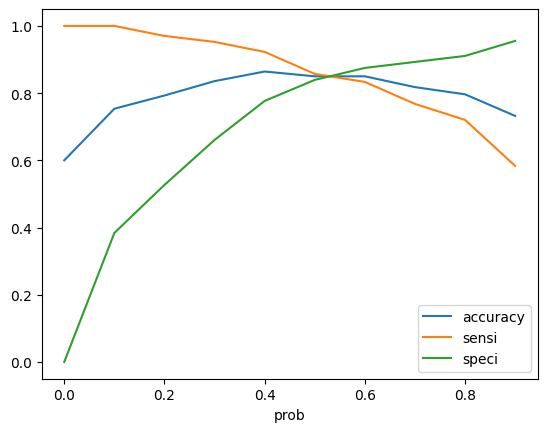

In [49]:
cutoff_df.plot.line(x='prob', y=['accuracy','sensi','speci'])
plt.show()

In [50]:
train_results['final_predicted'] = train_results.Probability.map( lambda x: 1 if x > 0.5 else 0)

train_results.head()

,Admit,Probability,Predicted_Admit,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,final_predicted
157,0,0.154708,0,1,1,0,0,0,0,0,0,0,0,0
109,0,0.391692,0,1,1,1,1,0,0,0,0,0,0,0
17,0,0.438712,0,1,1,1,1,1,0,0,0,0,0,0
347,0,0.003001,0,1,0,0,0,0,0,0,0,0,0,0
24,1,0.998349,1,1,1,1,1,1,1,1,1,1,1,1


In [51]:
print(metrics.accuracy_score(train_results.Admit, train_results.Predicted_Admit ))

0.8178571428571428


In [52]:
confusion2 = metrics.confusion_matrix(train_results.Admit, train_results.final_predicted )
confusion2

array([[ 94,  18],
       [ 24, 144]])

In [ ]:
TP = confusion2[1,1] # true positive
TN = confusion2[0,0] # true negatives
FP = confusion2[0,1] # false positives
FN = confusion2[1,0] # false negatives

In [57]:
TP / float(TP+FN)

np.float64(0.7678571428571429)

In [58]:
print(FP/ float(TN+FP))

0.10714285714285714


In [59]:
print (TP / float(TP+FP))

0.9148936170212766


In [60]:
print (TN / float(TN+ FN))

0.7194244604316546


In [61]:
from sklearn.metrics import precision_recall_curve

In [62]:
train_results.Admit, train_results.Predicted_Admit

(157    0
 109    0
 17     0
 347    0
 24     1
       ..
 71     1
 106    1
 270    1
 348    0
 102    0
 Name: Admit, Length: 280, dtype: int64,
 157    0
 109    0
 17     0
 347    0
 24     1
       ..
 71     1
 106    1
 270    0
 348    0
 102    0
 Name: Predicted_Admit, Length: 280, dtype: int64)

In [63]:
p, r, thresholds = precision_recall_curve(train_results.Admit, train_results.Probability)

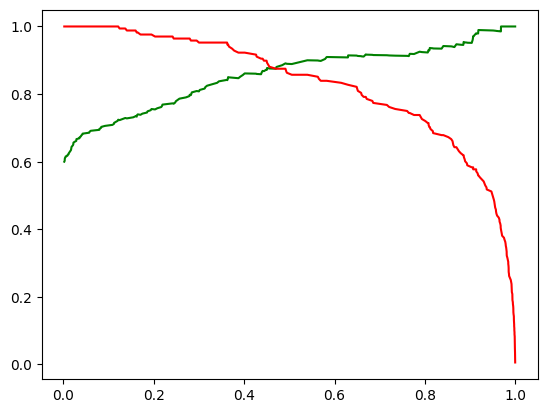

In [64]:
plt.plot(thresholds, p[:-1], "g-")
plt.plot(thresholds, r[:-1], "r-")
plt.show()

In [65]:
Recall = TP / float(TP+FN)
Recall

np.float64(0.7678571428571429)

In [67]:

Precision = TP / float(TP+FP)
Precision

np.float64(0.9148936170212766)

In [68]:
F1_score = (2* Recall * Precision)/ (Recall+Precision)
F1_score

np.float64(0.8349514563106796)